# <span style="color:slateblue"><b>Dependencies Import

In [67]:
# Imports
import pandas as pd
import numpy as np
import sklearn as skl
import tensorflow as tf
import seaborn as sn
import plotly.express as px
import scipy.stats as sp

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

# <span style="color:slateblue"><b>Data Load

In [2]:
# Load dataset
file_path = "./Resources/cumulative.csv"
keplerRAW_df = pd.read_csv(file_path)
keplerRAW_df

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,9560,10031643,K07984.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,0,0,...,-152.0,4.296,0.231,-0.189,1.088,0.313,-0.228,298.74921,46.973351,14.478
9560,9561,10090151,K07985.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,...,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
9561,9562,10128825,K07986.01,NaN,CANDIDATE,CANDIDATE,0.497,0,0,0,...,-220.0,4.444,0.056,-0.224,1.031,0.341,-0.114,286.50937,47.163219,14.757
9562,9563,10147276,K07987.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.021,0,0,1,...,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385


# <span style="color:slateblue"><b>EDA & Preprocessing

In [3]:
keplerRAW_df.dtypes

rowid                  int64
kepid                  int64
kepoi_name            object
kepler_name           object
koi_disposition       object
koi_pdisposition      object
koi_score            float64
koi_fpflag_nt          int64
koi_fpflag_ss          int64
koi_fpflag_co          int64
koi_fpflag_ec          int64
koi_period           float64
koi_period_err1      float64
koi_period_err2      float64
koi_time0bk          float64
koi_time0bk_err1     float64
koi_time0bk_err2     float64
koi_impact           float64
koi_impact_err1      float64
koi_impact_err2      float64
koi_duration         float64
koi_duration_err1    float64
koi_duration_err2    float64
koi_depth            float64
koi_depth_err1       float64
koi_depth_err2       float64
koi_prad             float64
koi_prad_err1        float64
koi_prad_err2        float64
koi_teq              float64
koi_teq_err1         float64
koi_teq_err2         float64
koi_insol            float64
koi_insol_err1       float64
koi_insol_err2

In [4]:
keplerRAW_df.describe()

,rowid,kepid,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
count,9564.000000,9.564000e+03,8054.000000,9564.000000,9564.000000,9564.000000,9564.000000,9564.000000,9110.000000,9110.000000,...,9081.000000,9201.000000,9096.000000,9096.000000,9201.000000,9096.000000,9096.000000,9564.000000,9564.000000,9563.000000
mean,4782.500000,7.690628e+06,0.480829,0.188206,0.231598,0.194898,0.120033,75.671358,0.002148,-0.002148,...,-162.265059,4.310157,0.120738,-0.143161,1.728712,0.362292,-0.394806,292.060163,43.810433,14.264606
std,2761.033321,2.653459e+06,0.476928,0.390897,0.421875,0.396143,0.325018,1334.744046,0.008236,0.008236,...,72.746348,0.432606,0.132837,0.085477,6.127185,0.930870,2.168213,4.766657,3.601243,1.385448
min,1.000000,7.574500e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.241843,0.000000,-0.172500,...,-1762.000000,0.047000,0.000000,-1.207000,0.109000,0.000000,-116.137000,279.852720,36.577381,6.966000
25%,2391.750000,5.556034e+06,0.000000,0.000000,0.000000,0.000000,0.000000,2.733684,0.000005,-0.000276,...,-198.000000,4.218000,0.042000,-0.196000,0.829000,0.129000,-0.250000,288.660770,40.777173,13.440000
50%,4782.500000,7.906892e+06,0.334000,0.000000,0.000000,0.000000,0.000000,9.752831,0.000035,-0.000035,...,-160.000000,4.438000,0.070000,-0.128000,1.000000,0.251000,-0.111000,292.261125,43.677504,14.520000
75%,7173.250000,9.873066e+06,0.998000,0.000000,0.000000,0.000000,0.000000,40.715178,0.000276,-0.000005,...,-114.000000,4.543000,0.149000,-0.088000,1.345000,0.364000,-0.069000,295.859160,46.714611,15.322000
max,9564.000000,1.293514e+07,1.000000,1.000000,1.000000,1.000000,1.000000,129995.778400,0.172500,0.000000,...,0.000000,5.364000,1.472000,0.000000,229.908000,33.091000,0.000000,301.720760,52.336010,20.003000


In [5]:
# change the index to the "kepoi_name" and drop the title
keplerProcessed_df = keplerRAW_df.set_index('kepoi_name')
keplerProcessed_df.rename_axis(None, inplace=True)

keplerProcessed_df 

,rowid,kepid,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
K00752.01,1,10797460,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
K00752.02,2,10797460,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
K00753.01,3,10811496,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
K00754.01,4,10848459,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
K00755.01,5,10854555,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
K07984.01,9560,10031643,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,0,0,1,...,-152.0,4.296,0.231,-0.189,1.088,0.313,-0.228,298.74921,46.973351,14.478
K07985.01,9561,10090151,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,1,0,...,-166.0,4.529,0.035,-0.196,0.903,0.237,-0.079,297.18875,47.093819,14.082
K07986.01,9562,10128825,NaN,CANDIDATE,CANDIDATE,0.497,0,0,0,0,...,-220.0,4.444,0.056,-0.224,1.031,0.341,-0.114,286.50937,47.163219,14.757
K07987.01,9563,10147276,NaN,FALSE POSITIVE,FALSE POSITIVE,0.021,0,0,1,0,...,-236.0,4.447,0.056,-0.224,1.041,0.341,-0.114,294.16489,47.176281,15.385


In [6]:
# Store relationships between the id, name, and dispositions 
keplerID_Names_df = keplerProcessed_df[["kepid","kepler_name","koi_disposition","koi_pdisposition"]]
keplerID_Names_df

,kepid,kepler_name,koi_disposition,koi_pdisposition
K00752.01,10797460,Kepler-227 b,CONFIRMED,CANDIDATE
K00752.02,10797460,Kepler-227 c,CONFIRMED,CANDIDATE
K00753.01,10811496,NaN,FALSE POSITIVE,FALSE POSITIVE
K00754.01,10848459,NaN,FALSE POSITIVE,FALSE POSITIVE
K00755.01,10854555,Kepler-664 b,CONFIRMED,CANDIDATE
...,...,...,...,...
K07984.01,10031643,NaN,FALSE POSITIVE,FALSE POSITIVE
K07985.01,10090151,NaN,FALSE POSITIVE,FALSE POSITIVE
K07986.01,10128825,NaN,CANDIDATE,CANDIDATE
K07987.01,10147276,NaN,FALSE POSITIVE,FALSE POSITIVE


In [7]:
# Drop columns that do not add value to the model

# koi_disposition and koi_score both have a high correlation to the target(y). Drop them
keplerProcessed_df.drop(["rowid","kepid","kepler_name","koi_disposition", "koi_score"], axis =1, inplace=True)

In [8]:
# Find and drop err columns
columns_to_drop = [col for col in keplerProcessed_df.columns if '_err' in col]

keplerProcessed_df = keplerProcessed_df.drop(columns=columns_to_drop)
keplerProcessed_df

,koi_pdisposition,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,...,koi_insol,koi_model_snr,koi_tce_plnt_num,koi_tce_delivname,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag
K00752.01,CANDIDATE,0,0,0,0,9.488036,170.538750,0.146,2.95750,615.8,...,93.59,35.8,1.0,q1_q17_dr25_tce,5455.0,4.467,0.927,291.93423,48.141651,15.347
K00752.02,CANDIDATE,0,0,0,0,54.418383,162.513840,0.586,4.50700,874.8,...,9.11,25.8,2.0,q1_q17_dr25_tce,5455.0,4.467,0.927,291.93423,48.141651,15.347
K00753.01,FALSE POSITIVE,0,1,0,0,19.899140,175.850252,0.969,1.78220,10829.0,...,39.30,76.3,1.0,q1_q17_dr25_tce,5853.0,4.544,0.868,297.00482,48.134129,15.436
K00754.01,FALSE POSITIVE,0,1,0,0,1.736952,170.307565,1.276,2.40641,8079.2,...,891.96,505.6,1.0,q1_q17_dr25_tce,5805.0,4.564,0.791,285.53461,48.285210,15.597
K00755.01,CANDIDATE,0,0,0,0,2.525592,171.595550,0.701,1.65450,603.3,...,926.16,40.9,1.0,q1_q17_dr25_tce,6031.0,4.438,1.046,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
K07984.01,FALSE POSITIVE,0,0,0,1,8.589871,132.016100,0.765,4.80600,87.7,...,176.40,8.4,1.0,q1_q17_dr25_tce,5638.0,4.296,1.088,298.74921,46.973351,14.478
K07985.01,FALSE POSITIVE,0,1,1,0,0.527699,131.705093,1.252,3.22210,1579.2,...,4500.53,453.3,1.0,q1_q17_dr25_tce,5638.0,4.529,0.903,297.18875,47.093819,14.082
K07986.01,CANDIDATE,0,0,0,0,1.739849,133.001270,0.043,3.11400,48.5,...,1585.81,10.6,1.0,q1_q17_dr25_tce,6119.0,4.444,1.031,286.50937,47.163219,14.757
K07987.01,FALSE POSITIVE,0,0,1,0,0.681402,132.181750,0.147,0.86500,103.6,...,5713.41,12.3,1.0,q1_q17_dr25_tce,6173.0,4.447,1.041,294.16489,47.176281,15.385


In [9]:
# Convert koi_tce_delivname to numeric dummies
keplerProcessed_df = pd.get_dummies(keplerProcessed_df, columns=["koi_tce_delivname"])
keplerProcessed_df

,koi_pdisposition,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,...,koi_tce_plnt_num,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag,koi_tce_delivname_q1_q16_tce,koi_tce_delivname_q1_q17_dr24_tce,koi_tce_delivname_q1_q17_dr25_tce
K00752.01,CANDIDATE,0,0,0,0,9.488036,170.538750,0.146,2.95750,615.8,...,1.0,5455.0,4.467,0.927,291.93423,48.141651,15.347,0,0,1
K00752.02,CANDIDATE,0,0,0,0,54.418383,162.513840,0.586,4.50700,874.8,...,2.0,5455.0,4.467,0.927,291.93423,48.141651,15.347,0,0,1
K00753.01,FALSE POSITIVE,0,1,0,0,19.899140,175.850252,0.969,1.78220,10829.0,...,1.0,5853.0,4.544,0.868,297.00482,48.134129,15.436,0,0,1
K00754.01,FALSE POSITIVE,0,1,0,0,1.736952,170.307565,1.276,2.40641,8079.2,...,1.0,5805.0,4.564,0.791,285.53461,48.285210,15.597,0,0,1
K00755.01,CANDIDATE,0,0,0,0,2.525592,171.595550,0.701,1.65450,603.3,...,1.0,6031.0,4.438,1.046,288.75488,48.226200,15.509,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
K07984.01,FALSE POSITIVE,0,0,0,1,8.589871,132.016100,0.765,4.80600,87.7,...,1.0,5638.0,4.296,1.088,298.74921,46.973351,14.478,0,0,1
K07985.01,FALSE POSITIVE,0,1,1,0,0.527699,131.705093,1.252,3.22210,1579.2,...,1.0,5638.0,4.529,0.903,297.18875,47.093819,14.082,0,0,1
K07986.01,CANDIDATE,0,0,0,0,1.739849,133.001270,0.043,3.11400,48.5,...,1.0,6119.0,4.444,1.031,286.50937,47.163219,14.757,0,0,1
K07987.01,FALSE POSITIVE,0,0,1,0,0.681402,132.181750,0.147,0.86500,103.6,...,1.0,6173.0,4.447,1.041,294.16489,47.176281,15.385,0,0,1


### <span style="color:red">NOTE: Using the koi_pdisposition for simplification since it has (2) values. Lets look at what it takes to use koi_disposition instead (has 4 values)</span>

In [10]:
# Convert koi_pdisposition to numeric, this will be the "target"
le = LabelEncoder()

keplerProcessed_df['koi_pdisposition'] = le.fit_transform(keplerProcessed_df['koi_pdisposition'])
keplerProcessed_df

,koi_pdisposition,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,...,koi_tce_plnt_num,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag,koi_tce_delivname_q1_q16_tce,koi_tce_delivname_q1_q17_dr24_tce,koi_tce_delivname_q1_q17_dr25_tce
K00752.01,0,0,0,0,0,9.488036,170.538750,0.146,2.95750,615.8,...,1.0,5455.0,4.467,0.927,291.93423,48.141651,15.347,0,0,1
K00752.02,0,0,0,0,0,54.418383,162.513840,0.586,4.50700,874.8,...,2.0,5455.0,4.467,0.927,291.93423,48.141651,15.347,0,0,1
K00753.01,1,0,1,0,0,19.899140,175.850252,0.969,1.78220,10829.0,...,1.0,5853.0,4.544,0.868,297.00482,48.134129,15.436,0,0,1
K00754.01,1,0,1,0,0,1.736952,170.307565,1.276,2.40641,8079.2,...,1.0,5805.0,4.564,0.791,285.53461,48.285210,15.597,0,0,1
K00755.01,0,0,0,0,0,2.525592,171.595550,0.701,1.65450,603.3,...,1.0,6031.0,4.438,1.046,288.75488,48.226200,15.509,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
K07984.01,1,0,0,0,1,8.589871,132.016100,0.765,4.80600,87.7,...,1.0,5638.0,4.296,1.088,298.74921,46.973351,14.478,0,0,1
K07985.01,1,0,1,1,0,0.527699,131.705093,1.252,3.22210,1579.2,...,1.0,5638.0,4.529,0.903,297.18875,47.093819,14.082,0,0,1
K07986.01,0,0,0,0,0,1.739849,133.001270,0.043,3.11400,48.5,...,1.0,6119.0,4.444,1.031,286.50937,47.163219,14.757,0,0,1
K07987.01,1,0,0,1,0,0.681402,132.181750,0.147,0.86500,103.6,...,1.0,6173.0,4.447,1.041,294.16489,47.176281,15.385,0,0,1


### <span style="color:orange">Processing of missing values (Nulls)

In [11]:
keplerProcessed_df.isnull().sum().sum()

3572

In [12]:
count_nan_in_df = keplerProcessed_df.isnull().sum()
print (count_nan_in_df)

koi_pdisposition                       0
koi_fpflag_nt                          0
koi_fpflag_ss                          0
koi_fpflag_co                          0
koi_fpflag_ec                          0
koi_period                             0
koi_time0bk                            0
koi_impact                           363
koi_duration                           0
koi_depth                            363
koi_prad                             363
koi_teq                              363
koi_insol                            321
koi_model_snr                        363
koi_tce_plnt_num                     346
koi_steff                            363
koi_slogg                            363
koi_srad                             363
ra                                     0
dec                                    0
koi_kepmag                             1
koi_tce_delivname_q1_q16_tce           0
koi_tce_delivname_q1_q17_dr24_tce      0
koi_tce_delivname_q1_q17_dr25_tce      0
dtype: int64


In [13]:
# Drop rows with NaN
keplerProcessedDropNull_df = keplerProcessed_df.copy(deep=True)
keplerProcessedDropNull_df = keplerProcessedDropNull_df.dropna()
keplerProcessedDropNull_df.isnull().sum().sum()

0

In [14]:
# Impute NaNs via Mean
imputer_mean = SimpleImputer(missing_values=np.nan, strategy='mean')

keplerProcessedMeanImpute_df = keplerProcessed_df.copy(deep=True)
keplerProcessedMeanImpute_df.iloc[:,:] = imputer_mean.fit_transform(keplerProcessedMeanImpute_df)
keplerProcessedMeanImpute_df.isnull().sum().sum()

0

In [15]:
# Impute NaNs via Median
imputer_median = SimpleImputer(missing_values=np.nan, strategy='median')

keplerProcessedMedianImpute_df = keplerProcessed_df.copy(deep=True)
keplerProcessedMedianImpute_df.iloc[:,:] = imputer_median.fit_transform(keplerProcessedMedianImpute_df)
keplerProcessedMedianImpute_df.isnull().sum().sum()

0

In [16]:
# Impute NaNs via Mode
imputer_mode = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

keplerProcessedModeImpute_df = keplerProcessed_df.copy(deep=True)
keplerProcessedModeImpute_df.iloc[:,:] = imputer_mode.fit_transform(keplerProcessedMeanImpute_df)
keplerProcessedModeImpute_df.isnull().sum().sum()

0

In [17]:
# Impute NaNs via MICE
# Multivariate Imputation By Chained Equations


### <span style="color:red"> Adjust the keplerProcessed_df based on the impute method being tested
    - CURRENT METHOD: "mean"

In [18]:
# Based on the Impute method being tested

#del keplerProcessed_df
#keplerProcessed_df = keplerProcessedDropNull_df
keplerProcessed_df = keplerProcessedMeanImpute_df
#keplerProcessed_df = keplerProcessedMedianImpute_df
#keplerProcessed_df = keplerProcessedModeImpute_df

keplerProcessed_df.isnull().sum().sum()

0

### <span style="color:orange">End of Null processing

### Analyze the column variance 
- helps determine which features aid the model

In [19]:
# Calculating Coefficient of Variation
cov_Koi_period = sp.variation(keplerProcessed_df["koi_period"])
cov_Koi_period

17.63777329266479

##### <span style="color:red">using the raw data for now, should we use the data after the Nulls are processed? Do nulls matter in these calcs?

In [20]:
# Find err columns & drop them
columns_to_drop = [col for col in keplerRAW_df.columns if '_err' in col]

# Delete err columns
variance_df = keplerRAW_df.drop(columns=columns_to_drop)

In [21]:
#Selecting only numeric columns
num_columns = variance_df.dtypes[variance_df.dtypes != "object"].index.tolist()
variance_df = variance_df[num_columns]
variance_df.head()

,rowid,kepid,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_time0bk,koi_impact,...,koi_teq,koi_insol,koi_model_snr,koi_tce_plnt_num,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag
0,1,10797460,1.000,0,0,0,0,9.488036,170.538750,0.146,...,793.0,93.59,35.8,1.0,5455.0,4.467,0.927,291.93423,48.141651,15.347
1,2,10797460,0.969,0,0,0,0,54.418383,162.513840,0.586,...,443.0,9.11,25.8,2.0,5455.0,4.467,0.927,291.93423,48.141651,15.347
2,3,10811496,0.000,0,1,0,0,19.899140,175.850252,0.969,...,638.0,39.30,76.3,1.0,5853.0,4.544,0.868,297.00482,48.134129,15.436
3,4,10848459,0.000,0,1,0,0,1.736952,170.307565,1.276,...,1395.0,891.96,505.6,1.0,5805.0,4.564,0.791,285.53461,48.285210,15.597
4,5,10854555,1.000,0,0,0,0,2.525592,171.595550,0.701,...,1406.0,926.16,40.9,1.0,6031.0,4.438,1.046,288.75488,48.226200,15.509


In [22]:
# Drop rowid and kepid
variance_df = variance_df.drop(columns=["rowid","kepid"])
variance_df

,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,...,koi_teq,koi_insol,koi_model_snr,koi_tce_plnt_num,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag
0,1.000,0,0,0,0,9.488036,170.538750,0.146,2.95750,615.8,...,793.0,93.59,35.8,1.0,5455.0,4.467,0.927,291.93423,48.141651,15.347
1,0.969,0,0,0,0,54.418383,162.513840,0.586,4.50700,874.8,...,443.0,9.11,25.8,2.0,5455.0,4.467,0.927,291.93423,48.141651,15.347
2,0.000,0,1,0,0,19.899140,175.850252,0.969,1.78220,10829.0,...,638.0,39.30,76.3,1.0,5853.0,4.544,0.868,297.00482,48.134129,15.436
3,0.000,0,1,0,0,1.736952,170.307565,1.276,2.40641,8079.2,...,1395.0,891.96,505.6,1.0,5805.0,4.564,0.791,285.53461,48.285210,15.597
4,1.000,0,0,0,0,2.525592,171.595550,0.701,1.65450,603.3,...,1406.0,926.16,40.9,1.0,6031.0,4.438,1.046,288.75488,48.226200,15.509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9559,0.000,0,0,0,1,8.589871,132.016100,0.765,4.80600,87.7,...,929.0,176.40,8.4,1.0,5638.0,4.296,1.088,298.74921,46.973351,14.478
9560,0.000,0,1,1,0,0.527699,131.705093,1.252,3.22210,1579.2,...,2088.0,4500.53,453.3,1.0,5638.0,4.529,0.903,297.18875,47.093819,14.082
9561,0.497,0,0,0,0,1.739849,133.001270,0.043,3.11400,48.5,...,1608.0,1585.81,10.6,1.0,6119.0,4.444,1.031,286.50937,47.163219,14.757
9562,0.021,0,0,1,0,0.681402,132.181750,0.147,0.86500,103.6,...,2218.0,5713.41,12.3,1.0,6173.0,4.447,1.041,294.16489,47.176281,15.385


In [23]:
# Check mean and standard deviation
stats_df = variance_df.describe().loc[['mean', 'std']]
stats_df

,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,...,koi_teq,koi_insol,koi_model_snr,koi_tce_plnt_num,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag
mean,0.480829,0.188206,0.231598,0.194898,0.120033,75.671358,166.183251,0.735105,5.621606,23791.335898,...,1085.385828,7745.737023,259.895001,1.243654,5706.823280,4.310157,1.728712,292.060163,43.810433,14.264606
std,0.476928,0.390897,0.421875,0.396143,0.325018,1334.744046,67.918960,3.348832,6.471554,82242.683149,...,856.351161,159204.665200,795.806615,0.664573,796.857947,0.432606,6.127185,4.766657,3.601243,1.385448


In [24]:
# Transpose the dataframe
stats_df = stats_df.T
stats_df.head()

,mean,std
koi_score,0.480829,0.476928
koi_fpflag_nt,0.188206,0.390897
koi_fpflag_ss,0.231598,0.421875
koi_fpflag_co,0.194898,0.396143
koi_fpflag_ec,0.120033,0.325018


In [25]:
# Add standard deviation ratios 
stats_df["ratio"]=stats_df["std"]/stats_df["mean"]
stats_df = stats_df.sort_values("ratio", ascending=False)
stats_df.head()

,mean,std,ratio
koi_prad,102.891778,3077.639126,29.911419
koi_insol,7745.737023,159204.665200,20.553843
koi_period,75.671358,1334.744046,17.638695
koi_impact,0.735105,3.348832,4.555580
koi_srad,1.728712,6.127185,3.544365


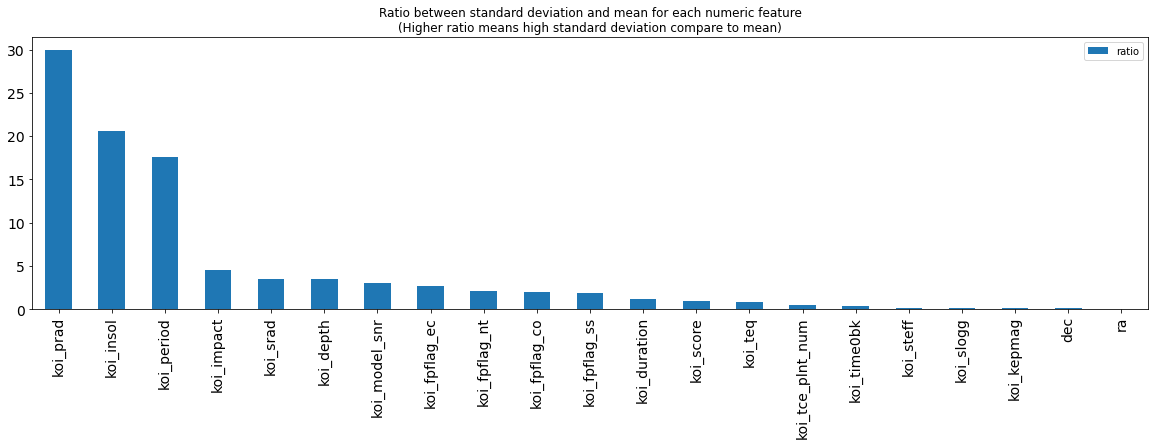

In [26]:
# Plot the standard deviation ratios columns
ax = stats_df.plot(y = "ratio", kind = "bar", figsize = (20,5), title = "Ratio between standard deviation and mean for each numeric feature\n(Higher ratio means high standard deviation compare to mean)", fontsize=14)

### Covariance Matrix - (long runtime)

In [27]:
#covMatrix = np.cov(keplerProcessed_df,bias=True)

#fig_covMatrix = px.imshow(covMatrix)
#fig_covMatrix.show()

### Correlation Matrix

In [28]:
keplerCorrMatrix = keplerProcessed_df.corr()
#print(keplerCorrMatrix) 

<AxesSubplot:>

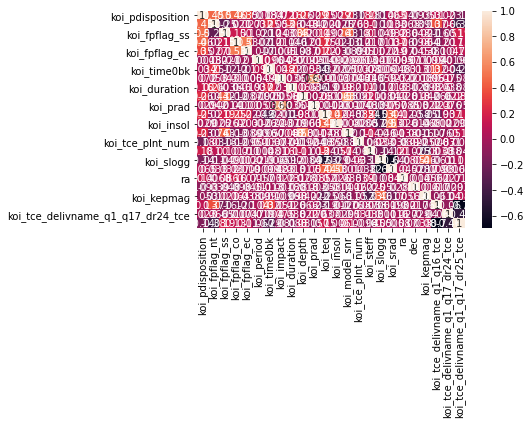

In [29]:
# Visualize the Correlation Matrix
sn.heatmap(keplerCorrMatrix, annot=True)

# *****increase the figure size


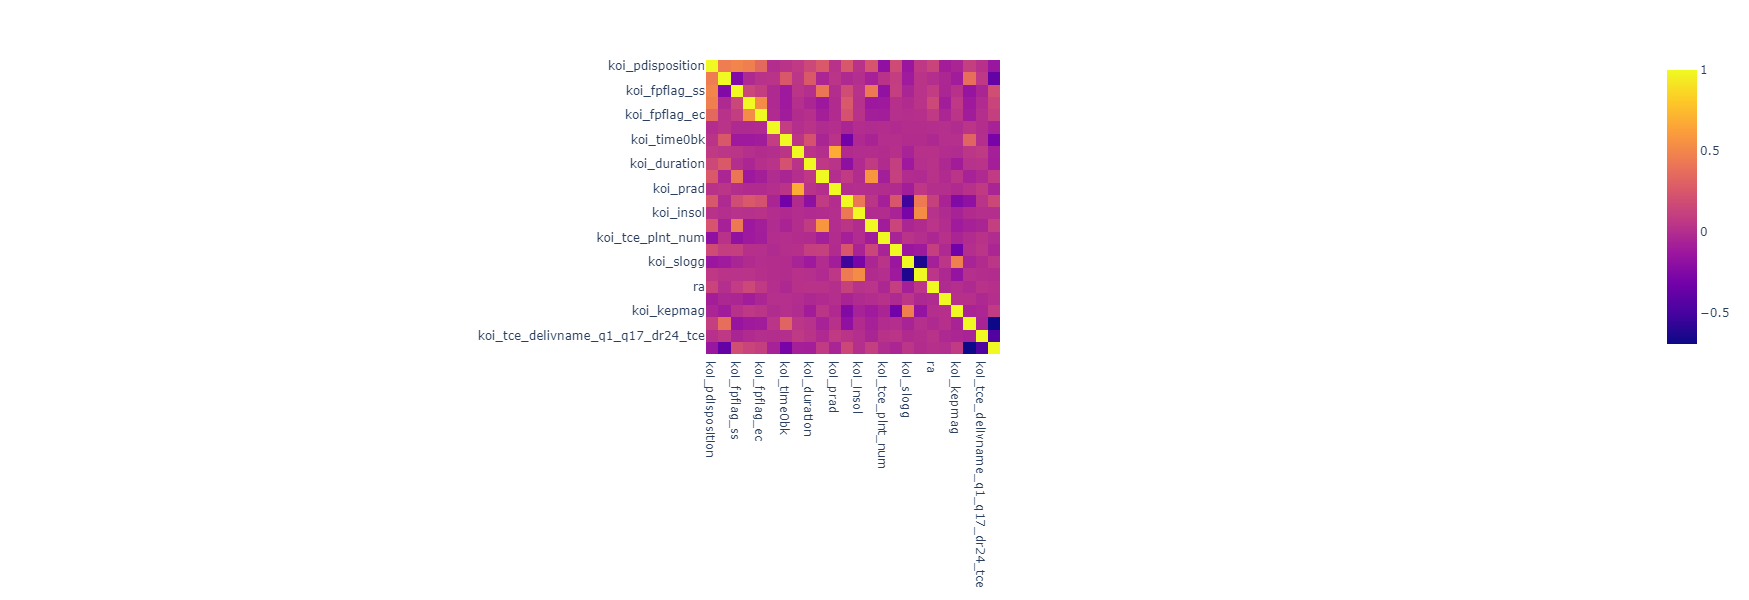

In [47]:
fig_corrMatrix = px.imshow(keplerCorrMatrix, width=1200, height=600)
fig_corrMatrix.update_yaxes(automargin=True)
fig_corrMatrix.show()

### Separate the Features (X) from the Target (y)

In [30]:
y = keplerProcessed_df["koi_pdisposition"]
X = keplerProcessed_df.drop(["koi_pdisposition"], axis =1)

### Split our data into training and testing

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    random_state=1, 
                                                    stratify=y)
X_train.shape

(7173, 23)

### Scale data

In [32]:
# Create a StandardScaler instance
scaler = StandardScaler()

# Fit the StandardScaler
X_scaler = scaler.fit(X_train)

# Scale the data
X_train_scaled = X_scaler.transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

# <span style="color:slateblue"><b>Supervised ML Logistic Regression Model

In [33]:
# Create the model
classifier = LogisticRegression(solver='lbfgs',
                                max_iter=200,
                                random_state=1)

In [34]:
# Train model
classifier.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=200, random_state=1)

In [64]:
# List the features sorted in descending order by feature importance
x = sorted(zip(classifier.coef_[0], X.columns), reverse=True)
featureImp = pd.DataFrame(np.array(x).reshape(len(x),2), columns = list(["Importance","Feature"]))
featureImp

,Importance,Feature
0,4.599222861831236,koi_fpflag_nt
1,4.543673048997104,koi_fpflag_co
2,3.7846268392897864,koi_fpflag_ss
3,3.4477643350675122,koi_fpflag_ec
4,1.1783437096492673,koi_depth
5,0.170800417979951,koi_duration
6,0.10132837821237248,koi_insol
7,0.08777295106122492,koi_impact
8,0.07797006528070612,ra
9,0.055989585074662826,koi_prad


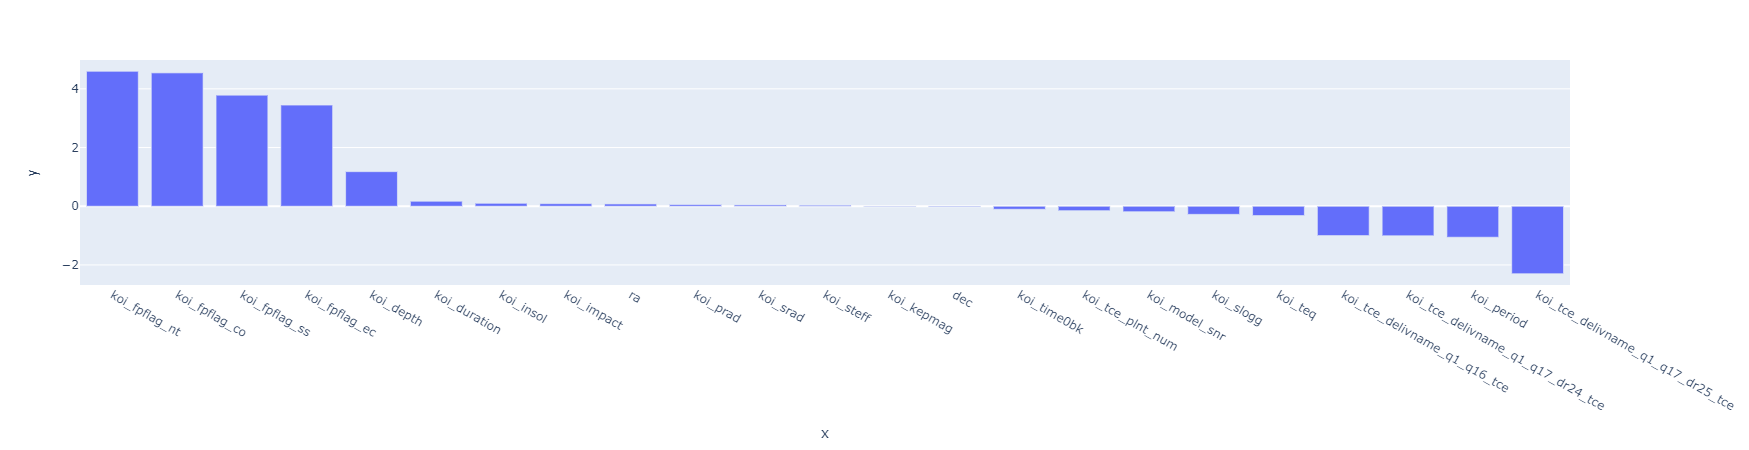

In [66]:
# Plot feature importance
plot_feature_Importance = px.bar(x=featureImp["Feature"], 
                                 y=featureImp["Importance"])
plot_feature_Importance.show()

In [36]:
# Make predictions
y_pred = classifier.predict(X_test_scaled)
results = pd.DataFrame({"Prediction": y_pred, "Actual": y_test}).reset_index(drop=True)
results

,Prediction,Actual
0,0.0,0.0
1,1.0,1.0
2,1.0,1.0
3,1.0,1.0
4,0.0,0.0
...,...,...
2386,0.0,0.0
2387,0.0,0.0
2388,0.0,0.0
2389,0.0,0.0


In [37]:
# from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.9891258887494772


# <span style="color:slateblue"><b>BASIC NEURAL NET w/ SIGMOID

### Build, Train and evaluate model

In [38]:
# Define the basic neural network model
nn_model = tf.keras.models.Sequential()
nn_model.add(tf.keras.layers.Dense(units=17, activation="relu", input_dim=23))
nn_model.add(tf.keras.layers.Dense(units=1, activation="sigmoid"))

# Compile 
nn_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

# Train
fit_model = nn_model.fit(X_train_scaled, y_train, epochs=100)

# Evaluate the model using the test data
model_loss, model_accuracy = nn_model.evaluate(X_test_scaled,y_test,verbose=2)
print(f"Loss: {model_loss}, Accuracy: {model_accuracy}")

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Epoch 1/100
7173/7173 [==============================] - 0s 32us/sample - loss: 0.4759 - acc: 0.7972
Epoch 2/100
7173/7173 [==============================] - 0s 22us/sample - loss: 0.1912 - acc: 0.9672
Epoch 3/100
7173/7173 [==============================] - 0s 21us/sample - loss: 0.1051 - acc: 0.9801
Epoch 4/100
7173/7173 [==============================] - 0s 21us/sample - loss: 0.0744 - acc: 0.9819
Epoch 5/100
7173/7173 [==============================] - 0s 22us/sample - loss: 0.0600 - acc: 0.9842
Epoch 6/100
7173/7173 [==============================] - 0s 22us/sample - loss: 0.0525 - acc: 0.9855
Epoch 7/100
7173/7173 [==============================] - 0s 22us/sample - loss: 0.0475 - acc: 0.9858
Epoch 8/100
7173/7173 [==============================] - 0s 20us/sample - loss: 0

# <span style="color:slateblue"><b>Visualizations

In [39]:
confirmed = keplerRAW_df[keplerRAW_df.koi_disposition == 'CONFIRMED']

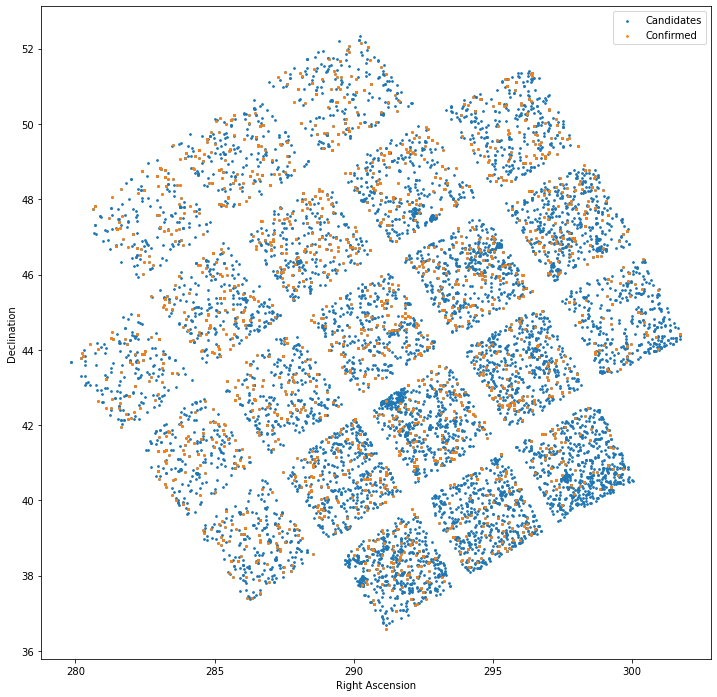

In [40]:
fig = plt.figure(figsize=(12, 12))

plt.scatter(keplerRAW_df.ra, keplerRAW_df.dec, s=3, label='Candidates')
plt.scatter(confirmed.ra, confirmed.dec, s=3, label="Confirmed")

plt.xlabel("Right Ascension")
plt.ylabel("Declination")

plt.legend()

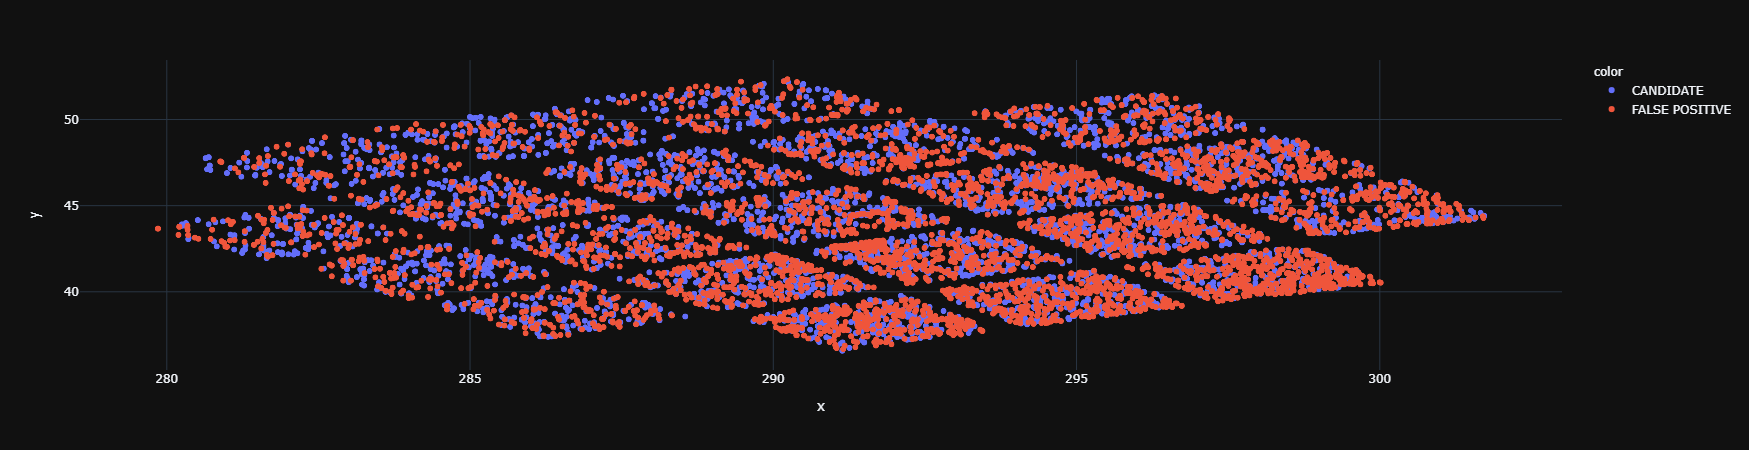

In [41]:
plot = px.scatter(x=keplerRAW_df["ra"], 
                  y=keplerRAW_df["dec"], 
                  color = keplerRAW_df["koi_pdisposition"], 
                  template="plotly_dark"
                 )
plot.show()

# ******Gabe suggestion - add density plots? to highlighting why each area may be more dense